<a href="https://colab.research.google.com/github/Cosider24/machine-learning-fundamentals/blob/main/13-cifar10-augmentation-strength-comparison/%D0%A1%D1%80%D0%B0%D0%B2%D0%BD%D0%B5%D0%BD%D0%B8%D0%B5_%D1%81%D0%B8%D0%BB%D1%8B_%D0%B0%D1%83%D0%B3%D0%BC%D0%B5%D0%BD%D1%82%D0%B0%D1%86%D0%B8%D0%B8.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Работа 8_2
# Аугментация данных для классификации изображений CIFAR-10

## Цель работы

Освоить применение аугментации данных при обучении сверточных нейронных сетей для задачи классификации изображений.

В ходе работы необходимо:

- загрузить и подготовить набор данных CIFAR-10;
- изучить примеры изображений из датасета;
- создать слой аугментации изображений;
- визуально оценить, как меняются изображения после аугментации;
- обучить CNN с использованием аугментации;
- построить графики обучения;
- проанализировать качество модели;
- сделать вывод о влиянии аугментации на обучение.

## Что такое аугментация данных?

**Аугментация данных** — это способ искусственно увеличить разнообразие обучающей выборки за счёт случайных преобразований изображений.

Например, изображение можно:

- немного повернуть;
- сдвинуть;
- приблизить или отдалить;
- отразить по горизонтали;
- изменить контрастность.

При этом объект на изображении должен остаться тем же самым.

Например, если на изображении был автомобиль, то после небольшого сдвига или отражения это всё ещё автомобиль.



## Шаг 1. Импорт библиотек

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.datasets import cifar10
from tensorflow.keras.utils import to_categorical
from sklearn.model_selection import train_test_split

## Шаг 2. Загрузка данных CIFAR-10

Набор данных CIFAR-10 содержит 60 000 цветных изображений размером 32×32 пикселя.

В датасете 10 классов:

0. самолёт  
1. автомобиль  
2. птица  
3. кот  
4. олень  
5. собака  
6. лягушка  
7. лошадь  
8. корабль  
9. грузовик

In [ ]:
(X_train, y_train), (X_test, y_test) = cifar10.load_data()

classes = [
    "самолет", "автомобиль", "птица", "кот", "олень",
    "собака", "лягушка", "лошадь", "корабль", "грузовик"
]

print("Размер обучающей выборки:", X_train.shape)
print("Размер тестовой выборки:", X_test.shape)
print("Размер одного изображения:", X_train[0].shape)

Размер обучающей выборки: (50000, 32, 32, 3)
Размер тестовой выборки: (10000, 32, 32, 3)
Размер одного изображения: (32, 32, 3)


## Шаг 3. Визуализация случайных изображений

Посмотрим на изображения из обучающей выборки.

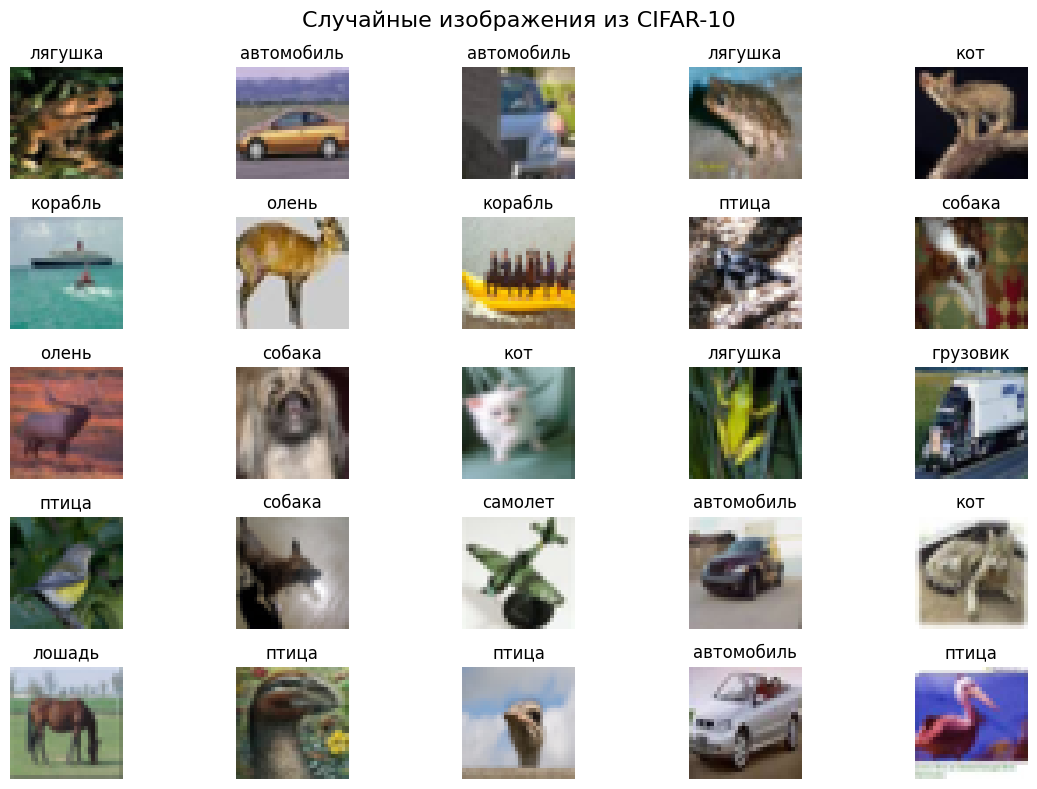

In [ ]:
plt.figure(figsize=(12, 8))

for i in range(25):
    index = np.random.randint(0, len(X_train))
    plt.subplot(5, 5, i + 1)
    plt.imshow(X_train[index])
    plt.title(classes[y_train[index][0]])
    plt.axis("off")

plt.suptitle("Случайные изображения из CIFAR-10", fontsize=16)
plt.tight_layout()
plt.show()

## Шаг 4. Визуализация изображений по классам

Отобразите по одному примеру для каждого класса.

## Шаг 5. Подготовка данных

Перед обучением модели нужно:

1. нормализовать изображения;
2. преобразовать метки классов в one-hot encoding;
3. разделить обучающую выборку на обучающую и валидационную части.

### Нормализация

Изначально значения пикселей находятся в диапазоне от 0 до 255.  
Мы приведём их к диапазону от 0 до 1.

### One-hot encoding

Метка класса превращается в вектор длины 10.

Например, класс `3` превращается в:

```python
[0, 0, 0, 1, 0, 0, 0, 0, 0, 0]
```

## Шаг 6. Создание слоя аугментации

Создайте последовательность случайных преобразований.

Используются:

- `RandomFlip`;
- `RandomRotation`;
- `RandomZoom`;
- `RandomTranslation`;
- `RandomContrast`.

Эти слои будут изменять изображения только во время обучения модели.

## Шаг 7. Визуализация аугментации одного изображения

Посмотрите, как одно изображение меняется после применения случайных преобразований.

## Шаг 8. Визуализация аугментации нескольких изображений

Посмотрите, как аугментация выглядит для разных классов.

## Шаг 9. Создание модели CNN с аугментацией



*слой аугментации будет находиться в начале модели.

Используем выбранную архитектуру из лаб 7.2



## Шаг 10. Компиляция модели



## Шаг 11. Обучение модели

Смените среду выполнения на GPU и обучите модель на 15-30 эпохах.

## Шаг 12. Графики обучения

Постройте графики:

- точности на обучающей и валидационной выборках;
- функции потерь на обучающей и валидационной выборках.

Сравните графики loss с моделью без аугментации из лаб 7.

## Шаг 13. Оценка модели на тестовой выборке

Проверьте, как модель работает на новых данных.

## Шаг 14. Предсказания модели

Посмотрите, как модель классифицирует отдельные изображения из тестовой выборки.

## Шаг 15. Оцените, насколько ваша модель уверена в предсказании класса



## Шаг 18. Матрица ошибок

Постройте матрицу ошибок, чтобы посмотреть, какие классы модель чаще всего путает между собой.

# Контрольные вопросы

1. Что такое аугментация данных?
2. Почему аугментация может уменьшать переобучение?
3. Какие виды аугментации использовались в этой работе?
4. Что делает `RandomFlip("horizontal")`?
5. Что делает `RandomRotation`?
6. Что делает `RandomZoom`?
7. Почему модель с аугментацией может обучаться медленнее?
8. Улучшилась ли модель после выбранной вами аугментации?

# Лабораторная работа 8.2
# Исследование силы аугментации данных при классификации изображений CIFAR-10

## Цель работы

Цель лабораторной работы — исследовать, как сила аугментации влияет на качество обучения сверточной нейронной сети.

В предыдущей части лабораторной работы была рассмотрена базовая аугментация изображений. Во второй части необходимо провести эксперимент: обучить несколько моделей с разными наборами преобразований и сравнить их качество.

В ходе работы необходимо:

- загрузить и подготовить набор данных CIFAR-10;
- создать несколько вариантов аугментации изображений;
- визуально сравнить слабую, умеренную и усиленную аугментацию;
- обучить CNN с разными вариантами аугментации;
- построить графики обучения;
- сравнить качество моделей на тестовой выборке;
- сделать вывод о том, какая сила аугментации оказалась наиболее подходящей.

## Что значит «сила аугментации»?

Аугментация данных — это случайное изменение обучающих изображений. Например, изображение можно немного повернуть, сдвинуть, приблизить или изменить его контрастность.

Сила аугментации показывает, насколько заметными будут эти изменения. Если преобразования слабые, изображение почти не отличается от исходного. Если преобразования слишком сильные, объект может стать плохо различимым, и модель будет обучаться хуже.

Важно помнить: аугментация должна сохранять смысл изображения. Если на изображении был кот, после преобразования это всё ещё должен быть кот. Если изображение слишком сильно повернуть, обрезать или исказить, модель может получить не полезный, а вредный обучающий пример.

## Шаг 1. Создание трёх вариантов аугментации

В этой лабораторной работе будут использоваться три варианта аугментации:

1. **Слабая аугментация** — небольшие изменения изображения. Она обычно помогает модели стать устойчивее, но не слишком усложняет обучение.
2. **Умеренная аугментация** — средние по силе преобразования. Такой вариант часто является наиболее сбалансированным.
3. **Усиленная аугментация** — сильные преобразования. Она может помочь при переобучении, но может и ухудшить качество, если изображения становятся слишком искажёнными.

Все три варианта будут добавляться в начало модели как слой `keras.Sequential`.

Используйте набор загруженных данных из первой части лабораторной.

In [ ]:
weak_augmentation = keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.03),
    layers.RandomZoom(0.05),
    layers.RandomTranslation(0.03, 0.03),
], name='weak_augmentation')

medium_augmentation = keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.10),
    layers.RandomZoom(0.10),
    layers.RandomTranslation(0.10, 0.10),
    layers.RandomContrast(0.10),
], name='medium_augmentation')

strong_augmentation = keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.20),
    layers.RandomZoom(0.20),
    layers.RandomTranslation(0.15, 0.15),
    layers.RandomContrast(0.20),
], name='strong_augmentation')

## Шаг 2. Выполните визуальное сравнение силы аугментации




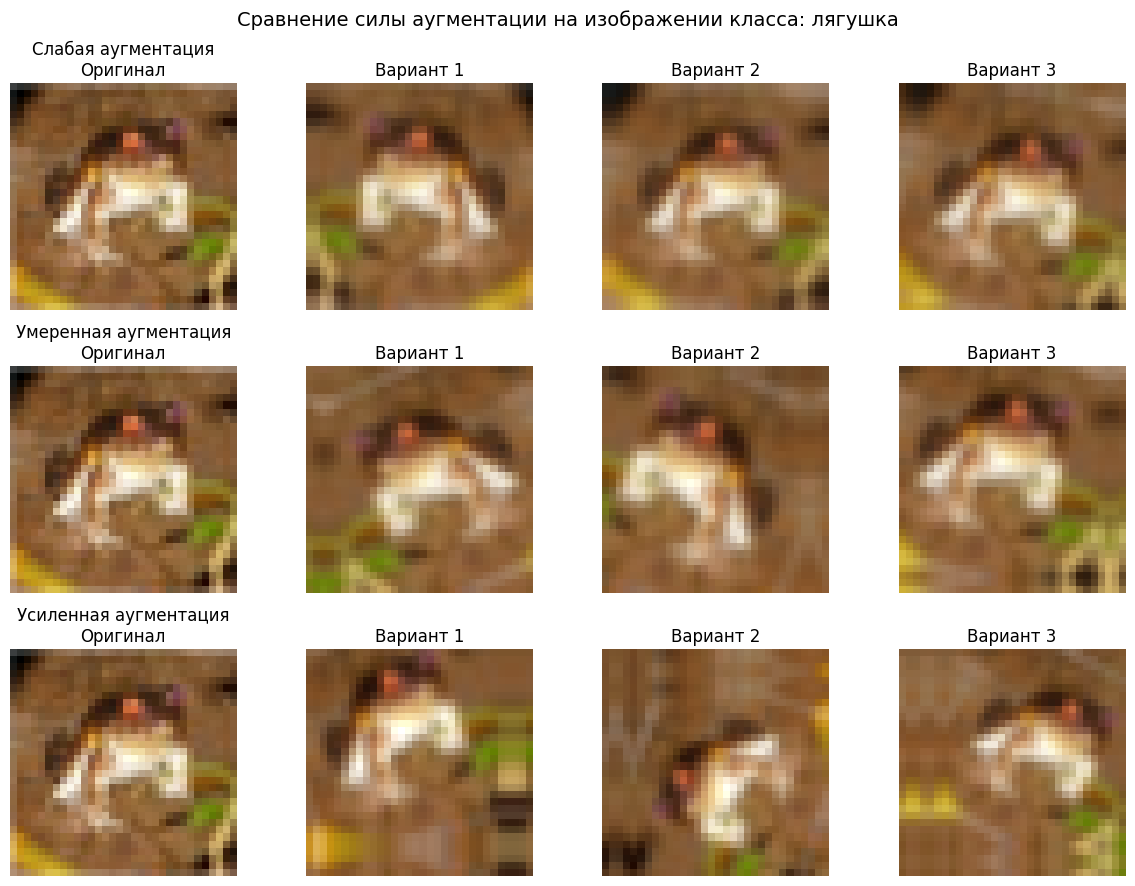

In [ ]:
image = X_train[0]
label = y_train[0][0]

def compare_augmentation_strengths(image, label, classes):
    augmentations = [
        (weak_augmentation, "Слабая аугментация"),
        (medium_augmentation, "Умеренная аугментация"),
        (strong_augmentation, "Усиленная аугментация")
    ]

    fig, axes = plt.subplots(3, 4, figsize=(12, 9))
    fig.suptitle(f"Сравнение силы аугментации на изображении класса: {classes[label]}", fontsize=14)

    for row, (aug_layer, title) in enumerate(augmentations):

        axes[row, 0].imshow(image)
        axes[row, 0].set_title(f"{title}\nОригинал")
        axes[row, 0].axis("off")

        for col in range(1, 4):

            augmented = aug_layer(tf.expand_dims(tf.cast(image, tf.float32), 0), training=True)[0]

            axes[row, col].imshow(tf.clip_by_value(augmented / 255.0, 0, 1))
            axes[row, col].set_title(f"Вариант {col}")
            axes[row, col].axis("off")

    plt.tight_layout()
    plt.show()

compare_augmentation_strengths(image, label, classes)

## Шаг 3. Постройте функцию создания CNN-модели



In [ ]:
def create_cnn_model(augmentation_layer):

    model = keras.Sequential([

        augmentation_layer,

        layers.Conv2D(32, (3, 3), activation='relu', padding='same', input_shape=(32, 32, 3)),
        layers.MaxPooling2D((2, 2)),

        layers.Conv2D(64, (3, 3), activation='relu', padding='same'),
        layers.MaxPooling2D((2, 2)),

        layers.Conv2D(128, (3, 3), activation='relu', padding='same'),
        layers.MaxPooling2D((2, 2)),

        layers.Flatten(),
        layers.Dense(128, activation='relu'),
        layers.Dropout(0.4),
        layers.Dense(10, activation='softmax')
    ])

    model.compile(
        optimizer='adam',
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )

    return model

print("Проверка создания модели со слабой аугментацией:")
test_model = create_cnn_model(weak_augmentation)
test_model.summary()

Проверка создания модели со слабой аугментацией:


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_8"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ weak_augmentation (Sequential)  │ (1, 32, 32, 3)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_24 (Conv2D)              │ (1, 32, 32, 32)        │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_24 (MaxPooling2D) │ (1, 16, 16, 32)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_25 (Conv2D)              │ (1, 16, 16, 64)        │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_25 (MaxPooling2D) │ (1, 8, 8, 64)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_26 (Conv2D)              │ (1, 8, 8, 128)         │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_26 (MaxPooling2D) │ (1, 4, 4, 128)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_8 (Flatten)             │ (1, 2048)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_16 (Dense)                │ (1, 128)               │       262,272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_8 (Dropout)             │ (1, 128)               │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_17 (Dense)                │ (1, 10)                │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 356,810 (1.36 MB)

 Trainable params: 356,810 (1.36 MB)

 Non-trainable params: 0 (0.00 B)

## Шаг 4. Обучение модели со слабой аугментацией

ВАЖНО: не забудьте сменить среду выполнения для ускорения обучения.

In [ ]:
X_train_normalized = X_train.astype('float32') / 255.0
X_test_normalized = X_test.astype('float32') / 255.0

y_train_f = to_categorical(y_train, num_classes=10)
y_test_f = to_categorical(y_test, num_classes=10)

model_weak = create_cnn_model(weak_augmentation)

print("Модель со СЛАБОЙ аугментацией")
print(f"Слой аугментации: {weak_augmentation.name}")

history_weak = model_weak.fit(
    X_train_normalized, y_train_f,
    validation_data=(X_test_normalized, y_test_f),
    epochs=15,
    batch_size=64,
    verbose=1
)

Модель со СЛАБОЙ аугментацией
Слой аугментации: weak_augmentation
Epoch 1/15
782/782 ━━━━━━━━━━━━━━━━━━━━ 10s 11ms/step - accuracy: 0.3875 - loss: 1.6694 - val_accuracy: 0.4777 - val_loss: 1.4012
Epoch 2/15
782/782 ━━━━━━━━━━━━━━━━━━━━ 9s 9ms/step - accuracy: 0.5232 - loss: 1.3397 - val_accuracy: 0.5667 - val_loss: 1.1750
Epoch 3/15
782/782 ━━━━━━━━━━━━━━━━━━━━ 8s 10ms/step - accuracy: 0.5822 - loss: 1.1822 - val_accuracy: 0.6228 - val_loss: 1.0630
Epoch 4/15
782/782 ━━━━━━━━━━━━━━━━━━━━ 8s 10ms/step - accuracy: 0.6206 - loss: 1.0830 - val_accuracy: 0.6696 - val_loss: 0.9482
Epoch 5/15
782/782 ━━━━━━━━━━━━━━━━━━━━ 7s 9ms/step - accuracy: 0.6456 - loss: 1.0144 - val_accuracy: 0.6806 - val_loss: 0.9170
Epoch 6/15
782/782 ━━━━━━━━━━━━━━━━━━━━ 11s 10ms/step - accuracy: 0.6669 - loss: 0.9603 - val_accuracy: 0.6780 - val_loss: 0.9413
Epoch 7/15
782/782 ━━━━━━━━━━━━━━━━━━━━ 8s 10ms/step - accuracy: 0.6806 - loss: 0.9159 - val_accuracy: 0.6997 - val_loss: 0.9053
Epoch 8/15
782/782 ━━━━━━━━━━━━

## Шаг 5. Обучение модели с умеренной аугментацией

Обучите модель с умеренной аугментацией.

In [ ]:
model_medium = create_cnn_model(medium_augmentation)

print("Модель с УМЕРЕННОЙ аугментацией")
print(f"Слой аугментации: {medium_augmentation.name}")

history_medium = model_medium.fit(
    X_train_normalized, y_train_f,
    validation_data=(X_test_normalized, y_test_f),
    epochs=15,
    batch_size=64,
    verbose=1
)

Модель с УМЕРЕННОЙ аугментацией
Слой аугментации: medium_augmentation
Epoch 1/15
782/782 ━━━━━━━━━━━━━━━━━━━━ 10s 10ms/step - accuracy: 0.3494 - loss: 1.7818 - val_accuracy: 0.4568 - val_loss: 1.4709
Epoch 2/15
782/782 ━━━━━━━━━━━━━━━━━━━━ 10s 10ms/step - accuracy: 0.4516 - loss: 1.5192 - val_accuracy: 0.5434 - val_loss: 1.2841
Epoch 3/15
782/782 ━━━━━━━━━━━━━━━━━━━━ 9s 12ms/step - accuracy: 0.4988 - loss: 1.3970 - val_accuracy: 0.5268 - val_loss: 1.3548
Epoch 4/15
782/782 ━━━━━━━━━━━━━━━━━━━━ 7s 9ms/step - accuracy: 0.5339 - loss: 1.3063 - val_accuracy: 0.5746 - val_loss: 1.2369
Epoch 5/15
782/782 ━━━━━━━━━━━━━━━━━━━━ 8s 10ms/step - accuracy: 0.5587 - loss: 1.2486 - val_accuracy: 0.6180 - val_loss: 1.0677
Epoch 6/15
782/782 ━━━━━━━━━━━━━━━━━━━━ 8s 10ms/step - accuracy: 0.5818 - loss: 1.1911 - val_accuracy: 0.6397 - val_loss: 1.0423
Epoch 7/15
782/782 ━━━━━━━━━━━━━━━━━━━━ 7s 9ms/step - accuracy: 0.5912 - loss: 1.1630 - val_accuracy: 0.6583 - val_loss: 0.9717
Epoch 8/15
782/782 ━━━━━━━━

## Шаг 6. Обучение модели с усиленной аугментацией

Обучите модель с усиленной аугментацией.

In [ ]:
model_strong = create_cnn_model(strong_augmentation)

print("Модель с УСИЛЕННОЙ аугментацией")
print(f"Слой аугментации: {strong_augmentation.name}")

history_strong = model_strong.fit(
    X_train_normalized, y_train_f,
    validation_data=(X_test_normalized, y_test_f),
    epochs=15,
    batch_size=64,
    verbose=1
)

Модель с УСИЛЕННОЙ аугментацией
Слой аугментации: strong_augmentation
Epoch 1/15
782/782 ━━━━━━━━━━━━━━━━━━━━ 10s 10ms/step - accuracy: 0.3009 - loss: 1.8971 - val_accuracy: 0.3874 - val_loss: 1.7130
Epoch 2/15
782/782 ━━━━━━━━━━━━━━━━━━━━ 8s 10ms/step - accuracy: 0.3929 - loss: 1.6778 - val_accuracy: 0.4810 - val_loss: 1.4238
Epoch 3/15
782/782 ━━━━━━━━━━━━━━━━━━━━ 8s 10ms/step - accuracy: 0.4319 - loss: 1.5826 - val_accuracy: 0.4926 - val_loss: 1.4306
Epoch 4/15
782/782 ━━━━━━━━━━━━━━━━━━━━ 8s 10ms/step - accuracy: 0.4578 - loss: 1.5101 - val_accuracy: 0.5294 - val_loss: 1.3192
Epoch 5/15
782/782 ━━━━━━━━━━━━━━━━━━━━ 8s 10ms/step - accuracy: 0.4822 - loss: 1.4506 - val_accuracy: 0.5337 - val_loss: 1.3109
Epoch 6/15
782/782 ━━━━━━━━━━━━━━━━━━━━ 10s 10ms/step - accuracy: 0.4954 - loss: 1.4130 - val_accuracy: 0.5632 - val_loss: 1.2030
Epoch 7/15
782/782 ━━━━━━━━━━━━━━━━━━━━ 7s 9ms/step - accuracy: 0.5087 - loss: 1.3785 - val_accuracy: 0.5836 - val_loss: 1.1531
Epoch 8/15
782/782 ━━━━━━━

## Шаг 7. Построение графиков обучения

После обучения трёх моделей необходимо сравнить графики точности и функции потерь.

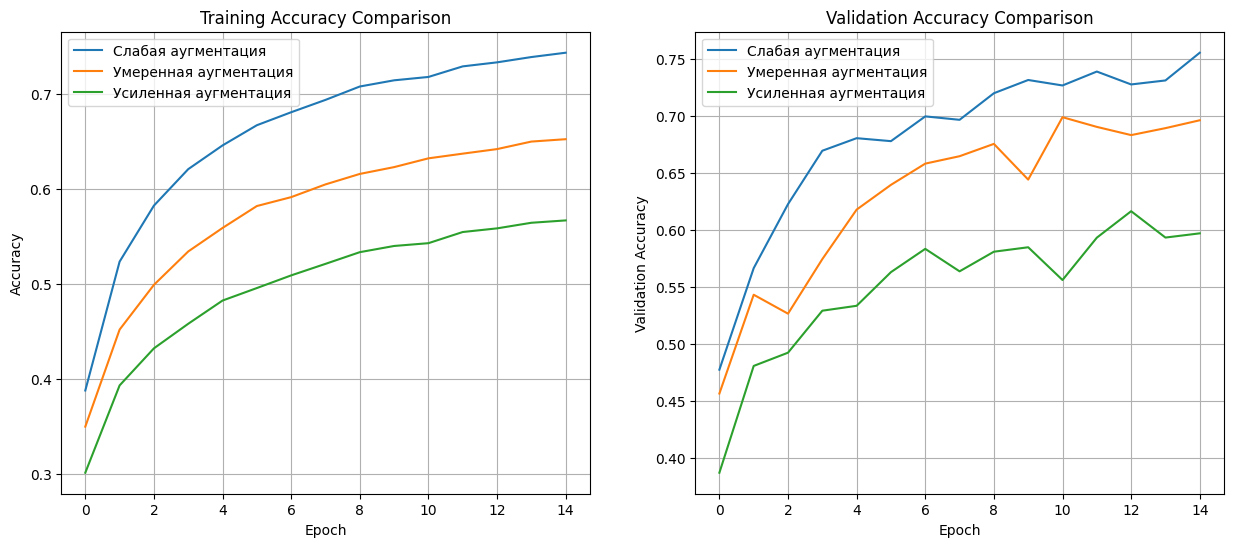

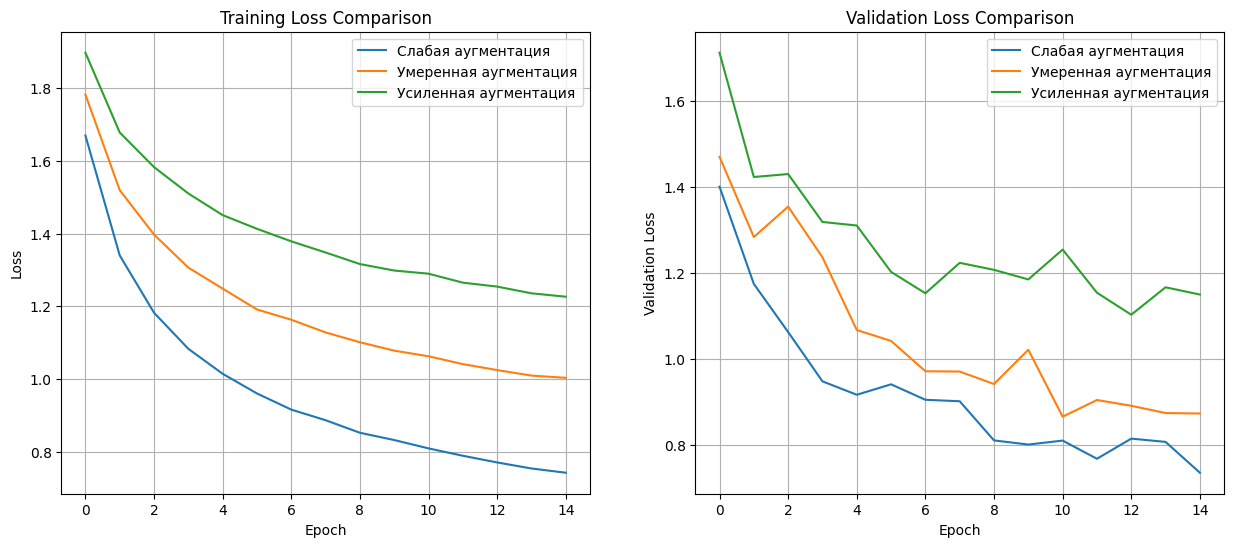

In [ ]:
def plot_comparison_history(history_list, title_list):
    plt.figure(figsize=(15, 6))

    plt.subplot(1, 2, 1)
    for i, history in enumerate(history_list):
        plt.plot(history.history['accuracy'], label=f'{title_list[i]}')
    plt.title('Training Accuracy Comparison')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.legend()
    plt.grid(True)

    plt.subplot(1, 2, 2)
    for i, history in enumerate(history_list):
        plt.plot(history.history['val_accuracy'], label=f'{title_list[i]}')
    plt.title('Validation Accuracy Comparison')
    plt.xlabel('Epoch')
    plt.ylabel('Validation Accuracy')
    plt.legend()
    plt.grid(True)
    plt.show()

    plt.figure(figsize=(15, 6))

    plt.subplot(1, 2, 1)
    for i, history in enumerate(history_list):
        plt.plot(history.history['loss'], label=f'{title_list[i]}')
    plt.title('Training Loss Comparison')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()
    plt.grid(True)

    plt.subplot(1, 2, 2)
    for i, history in enumerate(history_list):
        plt.plot(history.history['val_loss'], label=f'{title_list[i]}')
    plt.title('Validation Loss Comparison')
    plt.xlabel('Epoch')
    plt.ylabel('Validation Loss')
    plt.legend()
    plt.grid(True)
    plt.show()


history_objects = [history_weak, history_medium, history_strong]
model_titles = ['Слабая аугментация', 'Умеренная аугментация', 'Усиленная аугментация']

plot_comparison_history(history_objects, model_titles)

## Шаг 8. Подробные графики для каждой модели

Постройте графики `accuracy`, `val_accuracy`, `loss` и `val_loss` для каждой модели отдельно.

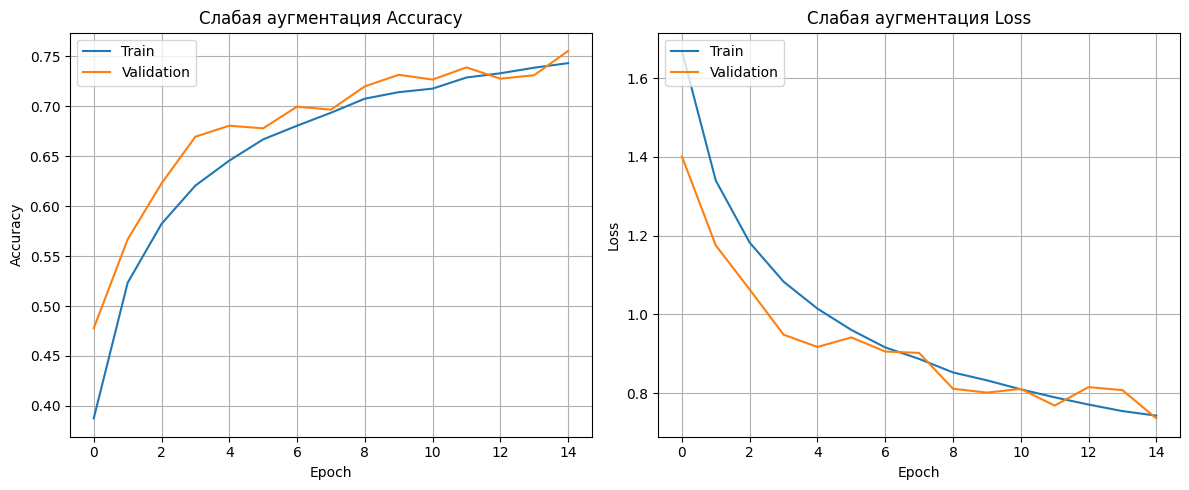

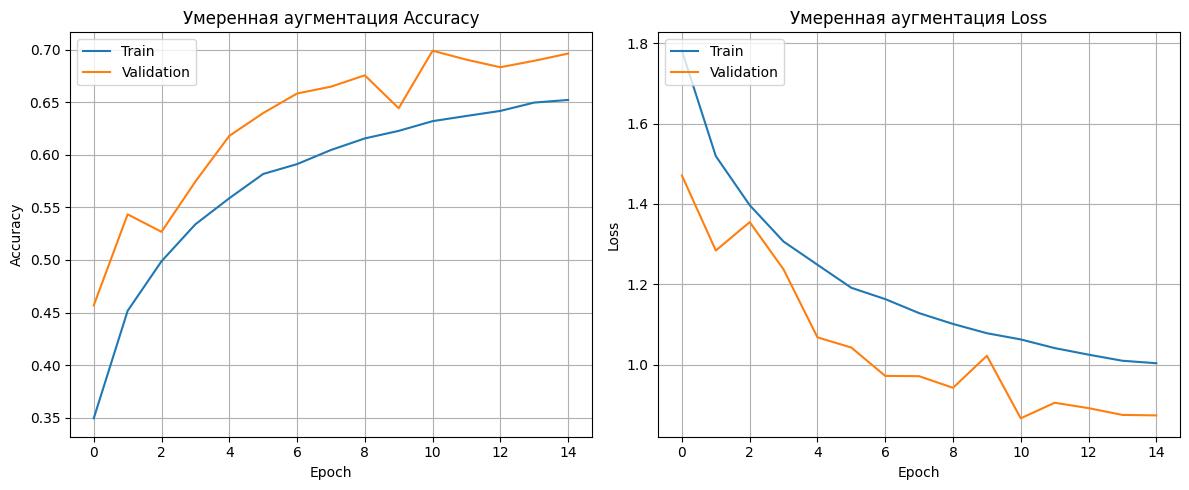

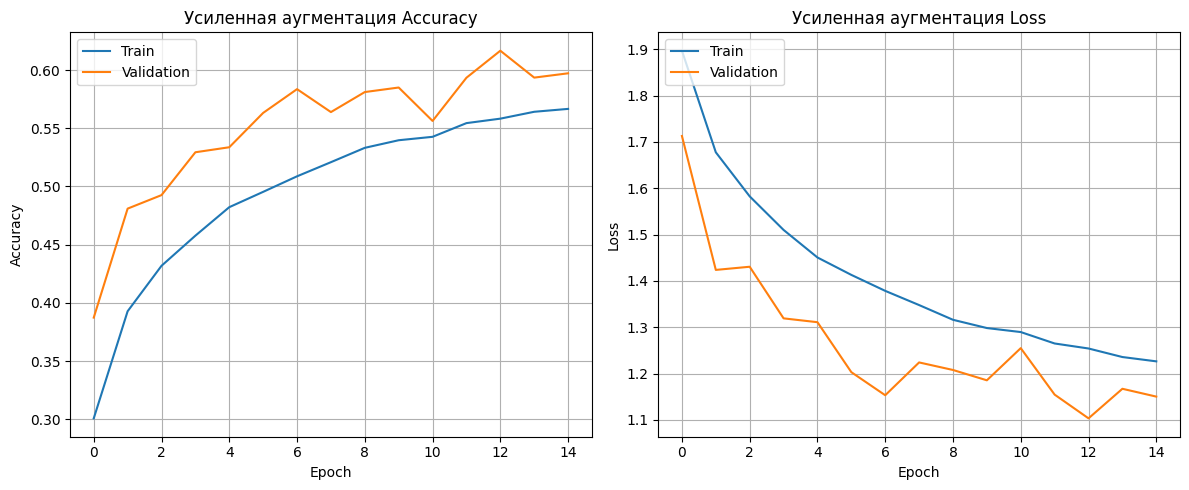

In [ ]:
def plot_individual_history(history, title):
    plt.figure(figsize=(12, 5))

    plt.subplot(1, 2, 1)
    plt.plot(history.history['accuracy'])
    plt.plot(history.history['val_accuracy'])
    plt.title(f'{title} Accuracy')
    plt.ylabel('Accuracy')
    plt.xlabel('Epoch')
    plt.legend(['Train', 'Validation'], loc='upper left')
    plt.grid(True)

    plt.subplot(1, 2, 2)
    plt.plot(history.history['loss'])
    plt.plot(history.history['val_loss'])
    plt.title(f'{title} Loss')
    plt.ylabel('Loss')
    plt.xlabel('Epoch')
    plt.legend(['Train', 'Validation'], loc='upper left')
    plt.grid(True)

    plt.tight_layout()
    plt.show()

for i in range(len(history_objects)):
    plot_individual_history(history_objects[i], model_titles[i])

## Шаг 9. Оценка моделей на тестовой выборке


Сравните три модели по значению `test_accuracy`.

In [ ]:
print('Оценка модели со слабой аугментацией:')
loss_weak, accuracy_weak = model_weak.evaluate(X_test_normalized, y_test_f, verbose=0)
print(f'Test Loss: {loss_weak:.4f}')
print(f'Test Accuracy: {accuracy_weak:.4f}\n')

print('Оценка модели с умеренной аугментацией:')
loss_medium, accuracy_medium = model_medium.evaluate(X_test_normalized, y_test_f, verbose=0)
print(f'Test Loss: {loss_medium:.4f}')
print(f'Test Accuracy: {accuracy_medium:.4f}\n')

print('Оценка модели с усиленной аугментацией:')
loss_strong, accuracy_strong = model_strong.evaluate(X_test_normalized, y_test_f, verbose=0)
print(f'Test Loss: {loss_strong:.4f}')
print(f'Test Accuracy: {accuracy_strong:.4f}\n')

print('Сводная таблица результатов на тестовой выборке:')
print(f'  Слабая аугментация:   Accuracy = {accuracy_weak:.4f}, Loss = {loss_weak:.4f}')
print(f'  Умеренная аугментация: Accuracy = {accuracy_medium:.4f}, Loss = {loss_medium:.4f}')
print(f'  Усиленная аугментация: Accuracy = {accuracy_strong:.4f}, Loss = {loss_strong:.4f}')

Оценка модели со слабой аугментацией:
Test Loss: 0.7356
Test Accuracy: 0.7555

Оценка модели с умеренной аугментацией:
Test Loss: 0.8733
Test Accuracy: 0.6963

Оценка модели с усиленной аугментацией:
Test Loss: 1.1502
Test Accuracy: 0.5972

Сводная таблица результатов на тестовой выборке:
  Слабая аугментация:   Accuracy = 0.7555, Loss = 0.7356
  Умеренная аугментация: Accuracy = 0.6963, Loss = 0.8733
  Усиленная аугментация: Accuracy = 0.5972, Loss = 1.1502


## Шаг 10. Предсказания лучшей модели

Выберите модель, которая показала лучший результат на тестовой выборке, и посмотрите её предсказания на отдельных изображениях.



313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step


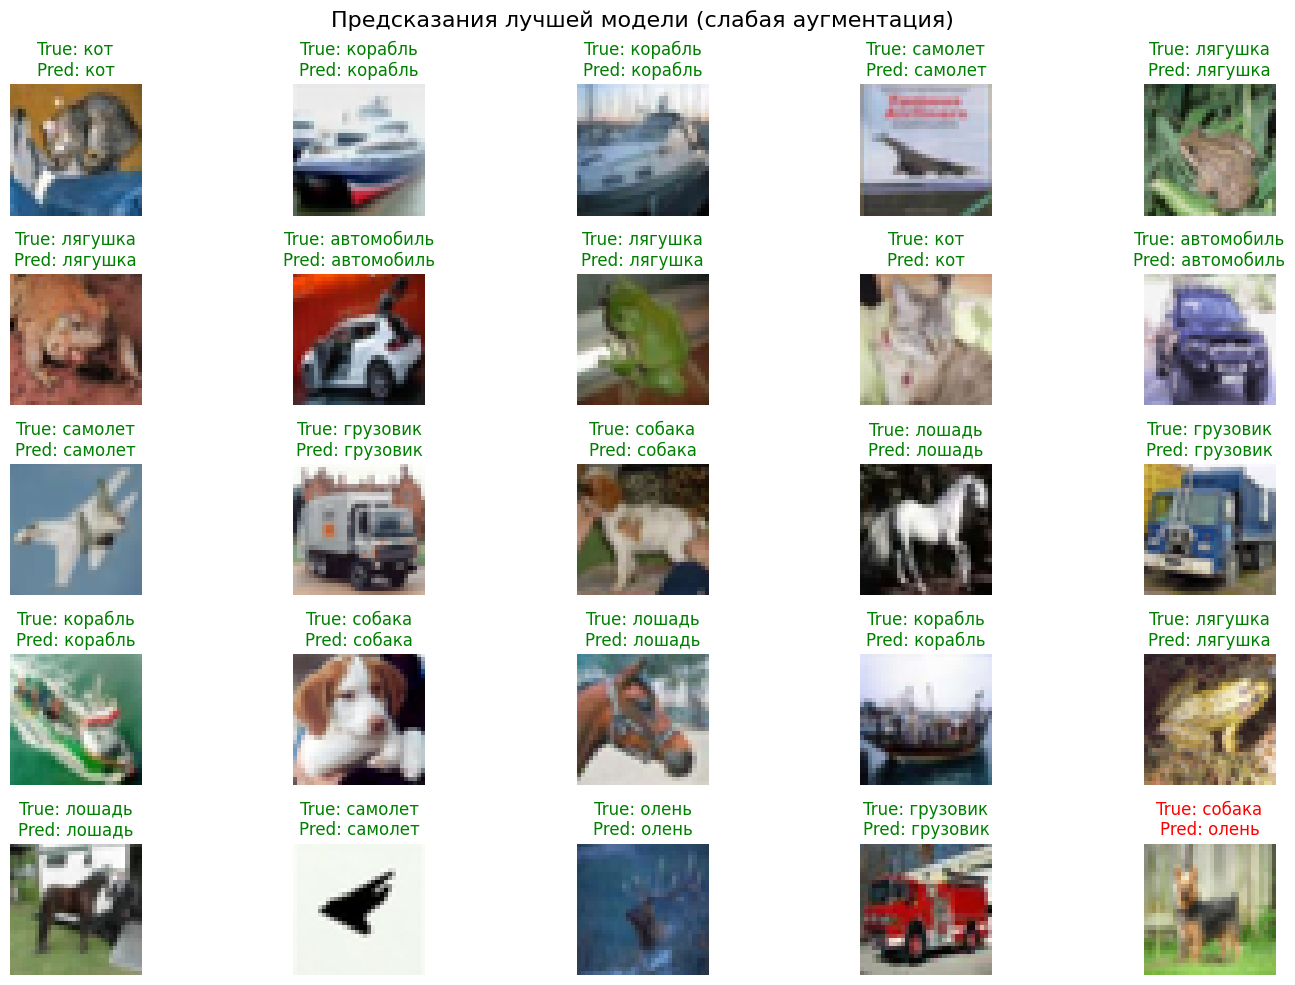

In [ ]:
best_model = model_weak

predictions = best_model.predict(X_test_normalized)
predicted_classes = np.argmax(predictions, axis=1)

plt.figure(figsize=(15, 10))
for i in range(25):
    plt.subplot(5, 5, i + 1)
    plt.imshow(X_test[i])
    true_label = classes[y_test[i][0]]
    pred_label = classes[predicted_classes[i]]
    color = "green" if true_label == pred_label else "red"
    plt.title(f"True: {true_label}\nPred: {pred_label}", color=color)
    plt.axis("off")

plt.suptitle("Предсказания лучшей модели (слабая аугментация)", fontsize=16)
plt.tight_layout()
plt.show()

## Шаг  11. Постройте матрицу ошибок для лучшей модели



313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


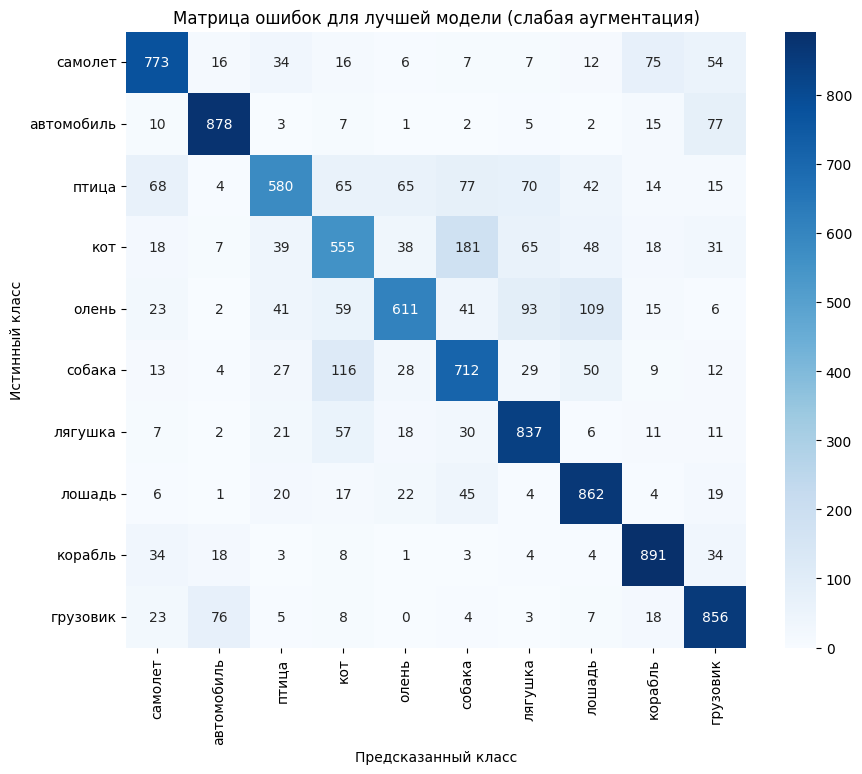

In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

y_pred_classes = np.argmax(best_model.predict(X_test_normalized), axis=1)
y_true_classes = np.argmax(y_test_f, axis=1)

cm = confusion_matrix(y_true_classes, y_pred_classes)

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=classes, yticklabels=classes)
plt.title('Матрица ошибок для лучшей модели (слабая аугментация)')
plt.xlabel('Предсказанный класс')
plt.ylabel('Истинный класс')
plt.show()

Анализ результатов

Ответьте на вопросы:

1. Какая аугментация дала наилучшее качество на тестовой выборке? со слабой ауг.
2. Какая аугментация дала самый стабильный график `val_loss`? слабая
3. У какой модели была самая высокая обучающая точность? слабая
4. У какой модели была самая высокая валидационная точность?слабая
5. Можно ли сказать, что усиленная аугментация всегда лучше слабой? Почему? иногда делает данные слишком слажными для обучения как сейчас
6. Были ли признаки переобучения у какой-либо модели?у усиленной
7. Какие классы модель чаще всего путала между собой? кошек с с обаками, грузовики с авто
8. Какой вариант аугментации вы бы выбрали для итоговой модели? слабую